In [2]:
import numpy as np
import pandas as pd
import pandas_datareader as data
import matplotlib.pyplot  as plt

In [3]:
start = '2010-01-01'
end = '2019-12-31'

df = data.DataReader('AAPL','stooq', start, end)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2019-12-31,70.3468,71.2544,70.2470,71.2476,1.040550e+08
2019-12-30,70.2332,71.0184,69.2041,70.7331,1.486153e+08
2019-12-27,70.6371,71.3265,69.9073,70.3141,1.508133e+08
2019-12-26,69.1093,70.3597,69.0804,70.3419,9.616825e+07
2019-12-24,69.0774,69.1261,68.6450,68.9740,4.994992e+07


In [4]:
df.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2010-01-08,6.34617,6.39407,6.30527,6.39387,5.296205e+08
2010-01-07,6.38439,6.39407,6.30478,6.35113,5.641458e+08
2010-01-06,6.46558,6.49137,6.35574,6.36237,6.513684e+08
2010-01-05,6.47811,6.50241,6.43181,6.46558,7.121486e+08
2010-01-04,6.43902,6.46922,6.40573,6.45451,5.819111e+08


In [5]:
df=df.reset_index()
df.head()

,Date,Open,High,Low,Close,Volume
0,2019-12-31,70.3468,71.2544,70.2470,71.2476,1.040550e+08
1,2019-12-30,70.2332,71.0184,69.2041,70.7331,1.486153e+08
2,2019-12-27,70.6371,71.3265,69.9073,70.3141,1.508133e+08
3,2019-12-26,69.1093,70.3597,69.0804,70.3419,9.616825e+07
4,2019-12-24,69.0774,69.1261,68.6450,68.9740,4.994992e+07


In [6]:
df = df.drop(['Date'], axis=1)

In [7]:
df

,Open,High,Low,Close,Volume
0,70.34680,71.25440,70.24700,71.24760,1.040550e+08
1,70.23320,71.01840,69.20410,70.73310,1.486153e+08
2,70.63710,71.32650,69.90730,70.31410,1.508133e+08
3,69.10930,70.35970,69.08040,70.34190,9.616825e+07
4,69.07740,69.12610,68.64500,68.97400,4.994992e+07
...,...,...,...,...,...
2511,6.34617,6.39407,6.30527,6.39387,5.296205e+08
2512,6.38439,6.39407,6.30478,6.35113,5.641458e+08
2513,6.46558,6.49137,6.35574,6.36237,6.513684e+08
2514,6.47811,6.50241,6.43181,6.46558,7.121486e+08


In [9]:
df = df.iloc[::-1]

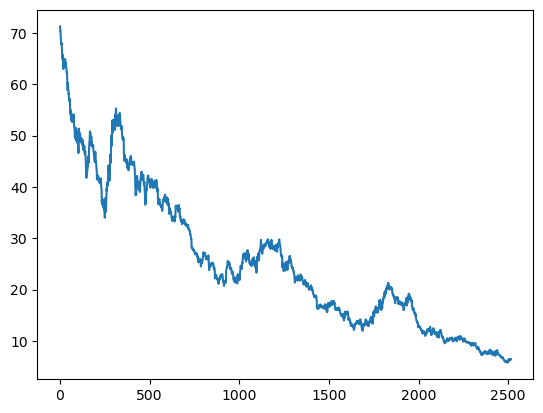

In [10]:
plt.plot(df.Close)

In [11]:
# Remove missing values
df = df.dropna()
# Remove duplicate entries
df = df.drop_duplicates()

In [12]:
train_size = int(len(df) * 0.7)

In [13]:
train, test = df.iloc[:train_size], df.iloc[train_size:]

In [14]:
data_train =pd.DataFrame(train['Close'])
data_test = pd.DataFrame(test['Close'])


In [15]:
print(f'x_train shape: {data_train.shape}')
print(f'y_train shape: {data_test.shape}')

x_train shape: (1761, 1)
y_train shape: (755, 1)


In [22]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 2515 to 755
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1761 non-null   float64
 1   High    1761 non-null   float64
 2   Low     1761 non-null   float64
 3   Close   1761 non-null   float64
 4   Volume  1761 non-null   float64
dtypes: float64(5)
memory usage: 68.9 KB


In [30]:
df.shape

(2516, 5)

In [32]:
data_train.head()

,Close
2515,6.45451
2514,6.46558
2513,6.36237
2512,6.35113
2511,6.39387


In [34]:
data_test.head()

,Close
754,26.8448
753,26.9229
752,26.8933
751,27.0325
750,27.3288


In [36]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 755 entries, 754 to 0
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   755 non-null    float64
dtypes: float64(1)
memory usage: 6.0 KB


In [38]:
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler(feature_range=(0,1))

In [39]:
df_training_array = scaler.fit_transform(data_train)

In [40]:
df_training_array

array([[0.02760406],
       [0.02806531],
       [0.02376491],
       ...,
       [0.89110874],
       [0.88637959],
       [0.88625876]])

In [41]:
x_train = []
y_train =[]
for i in  range(100,df_training_array.shape[0]):
    x_train.append(df_training_array[i-100: i])
    y_train.append(df_training_array[i, 0])

x_train, y_train = np.array(x_train),np.array(y_train)

In [42]:
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')

x_train shape: (1661, 100, 1)
y_train shape: (1661,)


In [43]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [49]:
model = Sequential()
model.add(LSTM(units = 50, activation='relu', return_sequences=True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences=True, ))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation='relu', return_sequences=True, ))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation='relu', return_sequences=False))
model.add(Dropout(0.5))


model.add(Dense(1))

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - loss: 0.1126
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0127
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0095
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0086
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0107
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0080
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0083
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0071
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0069
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0066
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0070
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0065
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0066
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0067
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0064
Epo

In [51]:
model.save('LSTM_model.keras')

In [52]:
df_testing_array = scaler.fit_transform(data_test)
df_testing_array

array([[0.        ],
       [0.0017589 ],
       [0.00109227],
       [0.00422721],
       [0.01090021],
       [0.01653049],
       [0.01719486],
       [0.02053249],
       [0.01799661],
       [0.01681651],
       [0.02181844],
       [0.02177565],
       [0.02071041],
       [0.02181844],
       [0.02231166],
       [0.02164053],
       [0.03165341],
       [0.03194168],
       [0.03200699],
       [0.03025034],
       [0.02891484],
       [0.06746647],
       [0.06644401],
       [0.06911276],
       [0.07567316],
       [0.08194753],
       [0.08452845],
       [0.0897556 ],
       [0.08813183],
       [0.09431387],
       [0.1032525 ],
       [0.10588296],
       [0.10505193],
       [0.10701352],
       [0.11215284],
       [0.11429459],
       [0.11106507],
       [0.11195015],
       [0.11330367],
       [0.11361896],
       [0.12836803],
       [0.12387507],
       [0.12832299],
       [0.12592224],
       [0.12689965],
       [0.12410028],
       [0.1224067 ],
       [0.124

In [53]:
df_testing_array.shape

(755, 1)

In [54]:
x_test = []
y_test = []
for i in  range(100,df_testing_array.shape[0]):
    x_test.append(df_testing_array[i-100: i])
    y_test.append(df_testing_array[i, 0])

x_test, y_test = np.array(x_test),np.array(y_test)

In [55]:
print(f'x_test shape: {x_test.shape}')
print(f'y_test shape: {y_test.shape}')

x_test shape: (655, 100, 1)
y_test shape: (655,)


In [56]:
y_pred  = model.predict(x_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step


In [57]:
y_pred.shape

(655, 1)

In [58]:
y_test.shape

(655,)

In [59]:
y_pred

array([[0.23663685],
       [0.23847927],
       [0.23996276],
       [0.24112323],
       [0.24199258],
       [0.24260977],
       [0.243047  ],
       [0.24336177],
       [0.24360722],
       [0.2438392 ],
       [0.24409756],
       [0.24433377],
       [0.24446331],
       [0.24441282],
       [0.24412557],
       [0.24354106],
       [0.24262519],
       [0.24140912],
       [0.23993586],
       [0.23826423],
       [0.23645413],
       [0.23456945],
       [0.23266387],
       [0.23075911],
       [0.22888884],
       [0.22706136],
       [0.22527863],
       [0.22353297],
       [0.22183022],
       [0.2201627 ],
       [0.21853933],
       [0.21698642],
       [0.21554106],
       [0.214243  ],
       [0.21316667],
       [0.21241078],
       [0.21206202],
       [0.21216998],
       [0.21273355],
       [0.21372758],
       [0.2150855 ],
       [0.21670711],
       [0.21853465],
       [0.22052804],
       [0.22260168],
       [0.22464868],
       [0.22656384],
       [0.228

In [60]:
scaler.scale_

array([0.0225211])

In [61]:
scale_factor = 1/0.02231132
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor

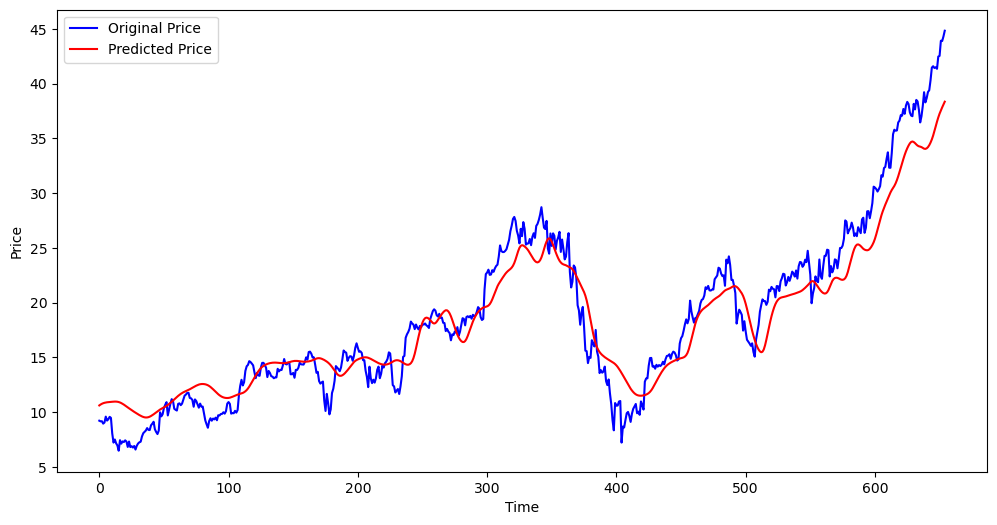

In [62]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b', label = 'Original Price')
plt.plot(y_pred,'r', label = 'Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()
           